In [1]:
import xarray as xr
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
root_dir = './..'
run = 'cpmip-nc400'
Nc = 400e6
var = ['twp','lwp','rwp','hmix']

dss = []
for i in range(len(var)):
    dss.append(xr.open_dataset(root_dir+'/'+run+'/cape-'+var[i]+'.nc'))
dss = xr.merge(dss)
dss

<xarray.Dataset> Size: 5GB
Dimensions:  (time: 312, xt: 960, yt: 960)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2020-02-01T16:05:00 ... 2020-02-02T18:...
  * xt       (xt) float64 8kB 75.0 225.0 375.0 ... 1.436e+05 1.438e+05 1.439e+05
  * yt       (yt) float64 8kB 75.0 225.0 375.0 ... 1.436e+05 1.438e+05 1.439e+05
Data variables:
    twp      (time, yt, xt) float32 1GB ...
    lwp      (time, yt, xt) float32 1GB ...
    rwp      (time, yt, xt) float32 1GB ...
    hmix     (time, yt, xt) float32 1GB ...
Attributes:
    CDI:          Climate Data Interface version 2.2.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    title:        000/cape.x000y000.001.nc
    history:      Mon Sep 09 21:49:53 2024: cdo -f nc4 -z zip_6 -r -O collgri...
    Source:       DALES 4.4.2 git: v4.4.1-499-g91d7ba
    Author:       
    CDO:          Climate Data Operators version 2.2.2 (https://mpimet.mpg.de...

In [3]:
tau = 0.19 * dss['lwp']**(5./6) * Nc**(1.0/3)
dss['alb'] = tau / (7.7 + tau)

In [4]:
# Cold pool fraction
def _mode(*args, **kwargs):
    vals = ss.mode(*args, **kwargs)
    # only return the mode (discard the count)
    return vals[0].squeeze()


def mode(obj, dim=None):
    # note: apply always moves core dimensions to the end
    # usually axis is simply -1 but scipy's mode function doesn't seem to like that
    # this means that this version will only work for DataArray's (not Datasets)
    assert isinstance(obj, xr.DataArray)
    axis = obj.ndim - 1
    return xr.apply_ufunc(_mode, obj.compute(),
                          input_core_dims=[obj.dims], # Pass all the dimensions in
                          output_core_dims=[obj.dims[:axis]], # Want all but the last dimension (z!) out
                          kwargs={'axis': axis,
                                  'keepdims':False})

In [5]:
# Get and stack
hmix = dss.hmix.stack(z=('xt', 'yt'))
lwp = dss.lwp.stack(z=('xt', 'yt'))

# Empty dataarray to be written to
da_cpfrac = xr.DataArray(dims = ['time'],
                         coords={'time':hmix.coords['time']}).rename('cpfrac')
# Get the ith member and (down)load all its time components into memory
hmixi = hmix.load()
lwpi = lwp.load()

# Mode
hmix_mode = mode(hmixi)

# xth percentile
thr = 0.975

hmix_upper = hmixi.quantile(thr,dim='z').values

# Below this number it's a cold pool, with a margin
margin = 1.1
cp_mask = xr.where(hmixi < 2*hmix_mode - hmix_upper*margin, 1, np.nan)
cp_num = cp_mask.count(dim='z').compute()
da_cpfrac[:] = cp_num/hmixi.z.size

da_cpfrac.to_netcdf(root_dir+'/'+run+'/cpfrac.nc', 'w')

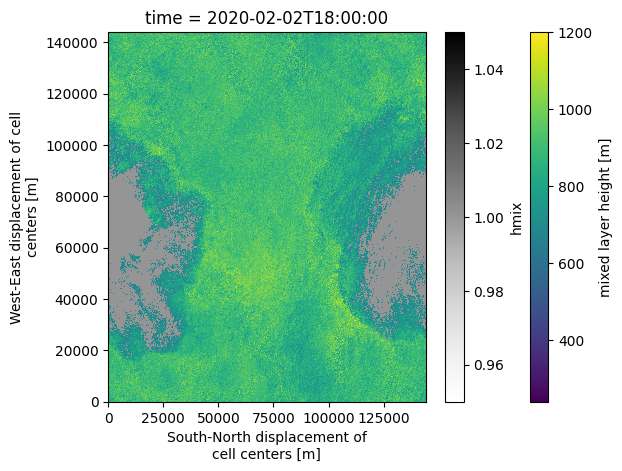

In [27]:
hmixi.isel(time=-1).unstack().plot()
cp_mask.isel(time=-1).unstack().plot(alpha=1,cmap='Greys')

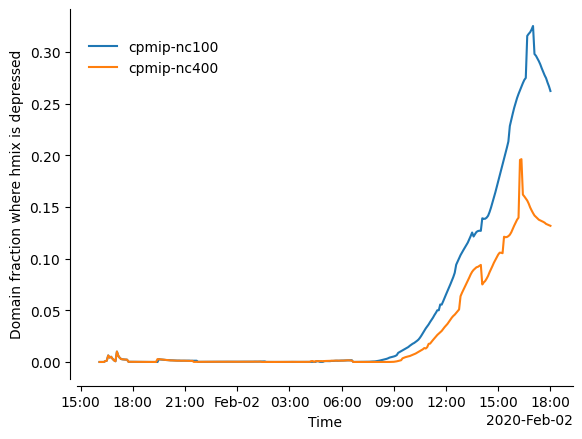

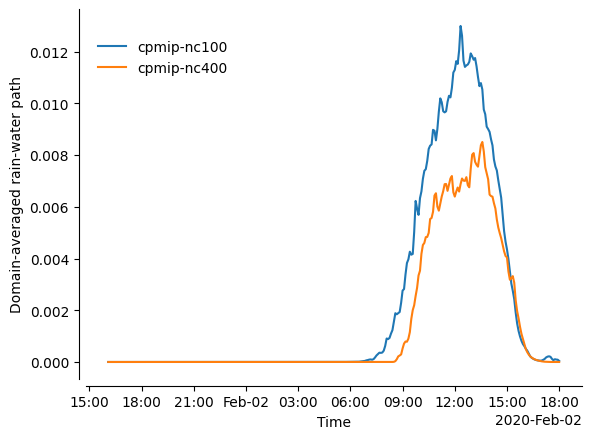

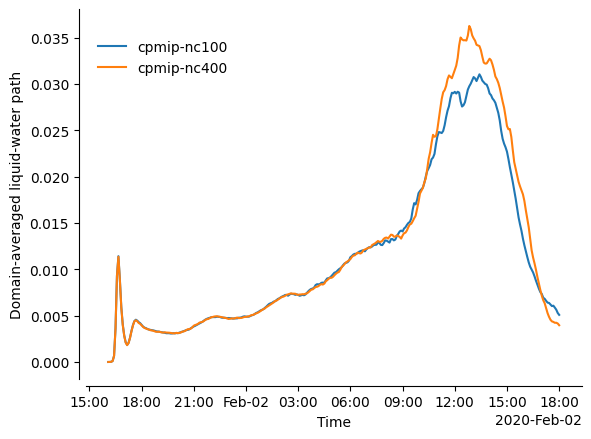

In [10]:
# Comparing
runs = ['cpmip-nc100','cpmip-nc400']

fig = plt.figure(); ax = plt.gca()
for r in range(len(runs)):
    cpf = xr.open_dataset(root_dir+'/'+runs[r]+'/cpfrac.nc')
    cpf['cpfrac'].plot(ax=ax,label=runs[r])
ax.legend(frameon=False, bbox_to_anchor=(0,0.95), loc='upper left')
ax.set_ylabel('Domain fraction where hmix is depressed')
sns.despine(offset=5)
plt.savefig('./figs/cpfrac-nc.pdf',bbox_inches='tight')

fig = plt.figure(); ax = plt.gca()
for r in range(len(runs)):
    rwpr = xr.open_dataset(root_dir+'/'+runs[r]+'/cape-rwp.nc')
    rwp = rwpr.rwp.mean(('xt','yt'))
    rwp.plot(ax=ax,label=runs[r])
ax.legend(frameon=False, bbox_to_anchor=(0,0.95), loc='upper left')
ax.set_ylabel('Domain-averaged rain-water path')
sns.despine(offset=5)
plt.savefig('./figs/rwp-nc.pdf',bbox_inches='tight')

fig = plt.figure(); ax = plt.gca()
for r in range(len(runs)):
    lwpr = xr.open_dataset(root_dir+'/'+runs[r]+'/cape-lwp.nc')
    lwp = lwpr.lwp.mean(('xt','yt'))
    lwp.plot(ax=ax,label=runs[r])
ax.legend(frameon=False, bbox_to_anchor=(0,0.95), loc='upper left')
ax.set_ylabel('Domain-averaged liquid-water path')
sns.despine(offset=5)
plt.savefig('./figs/lwp-nc.pdf',bbox_inches='tight')

In [12]:
# Comparing 2D fields

# Store separately
def plot_run(run, varpl, tplt):
    fig, ax = plt.subplots(figsize=(3,2.5))
    dspl = xr.open_dataset(root_dir+'/'+run+'/cape-'+varpl+'.nc')
    dapl = dspl[varpl].sel(time=tplt)
    if varpl == 'lwp':
        tau = 0.19 * dapl**(5./6) * Nc**(1.0/3)
        dapl = (tau / (7.7 + tau)).rename('Cloud albedo')
    dapl.plot(ax=ax)
    if run == runs[0]:
        ax.set_title(run+'\n'+tplt)
    else:
        ax.set_title(run)
    plt.savefig('./figs/twod'+run+'-'+varpl+'-'+tplt.replace(" ", "")+'.png',
                dpi=300,bbox_inches='tight')


In [10]:
runs = ['cpmip-nc100','cpmip-nc400']
varpl = ['lwp','hmix']
tplt = ['2020-02-02 09:00:00',
        '2020-02-02 12:00:00',
        '2020-02-02 15:00:00',
        '2020-02-02 18:00:00'
       ]

for i in range(len(runs)):
    for j in range(len(varpl)):
        for k in range(len(tplt)):
            plot_run(runs[i], varpl[j], tplt[k])
            plt.show()

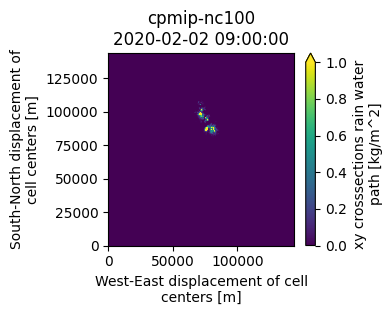

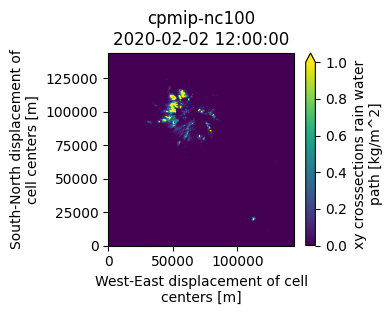

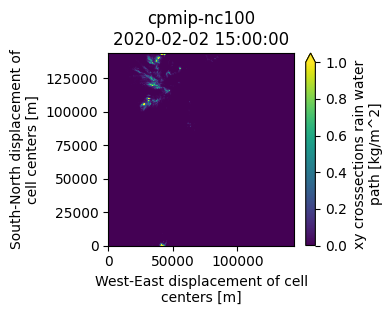

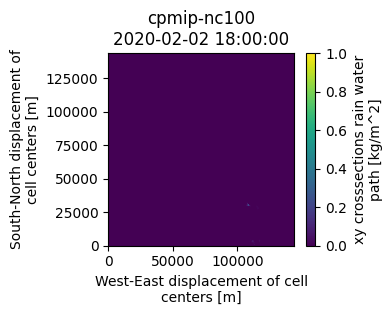

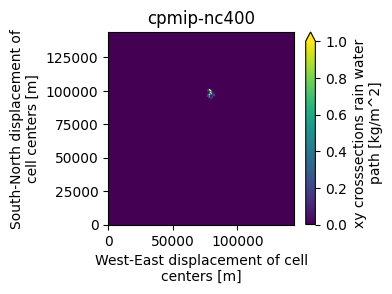

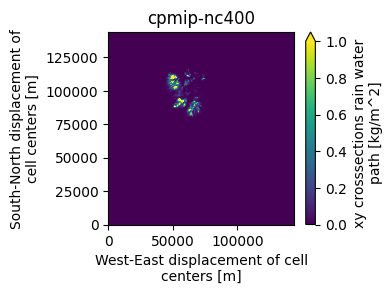

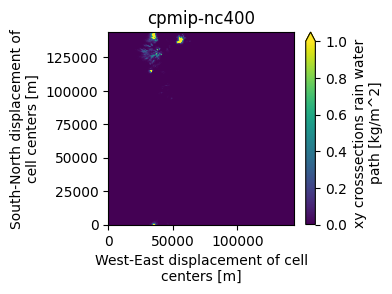

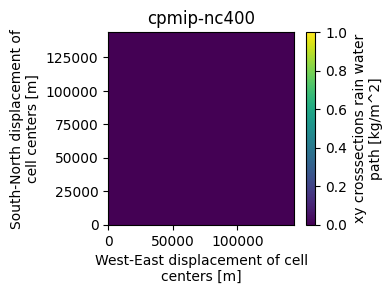

In [13]:
runs = ['cpmip-nc100','cpmip-nc400']
varpl = ['rwp']
tplt = ['2020-02-02 09:00:00',
        '2020-02-02 12:00:00',
        '2020-02-02 15:00:00',
        '2020-02-02 18:00:00'
       ]

for i in range(len(runs)):
    for j in range(len(varpl)):
        for k in range(len(tplt)):
            plot_run(runs[i], varpl[j], tplt[k])
            plt.show()

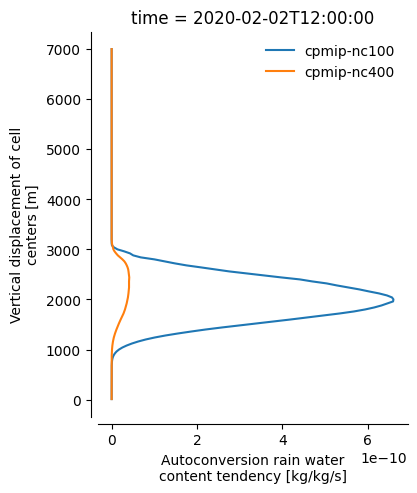

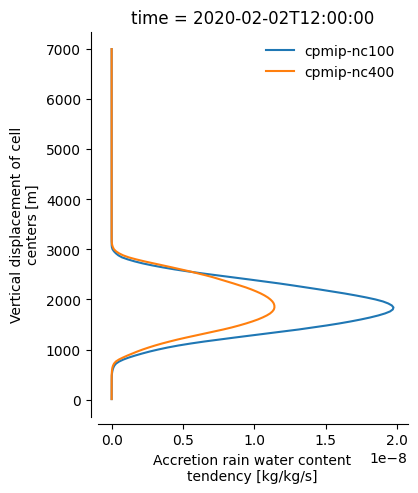

In [23]:
# 1D comparison
runs = ['cpmip-nc100','cpmip-nc400']
varpl = ['qrpauto','qrpaccr']
timeplt = ['2020-02-02 12:00:00']

def plot_1d(runs, varpl, timeplt):
    fig=plt.figure(figsize=(4,5)); ax=plt.gca()
    for i in range(len(runs)):
        ds1 = xr.open_dataset(root_dir+'/'+runs[i]+'/profiles.001.nc')
        ds1[varpl].sel(time=timeplt).plot(y='zt',ax=ax,label=runs[i])
    ax.legend(frameon=False)
    sns.despine(offset=5)
    plt.savefig('./figs/oned-comp-nc'+'-'+varpl+'-'+timeplt.replace(" ", "")+'.png',
                dpi=300,bbox_inches='tight')

for j in range(len(varpl)):
    for k in range(len(timeplt)):
        plot_1d(runs, varpl[j], timeplt[k])
